## Final Summary

### Goal
Develop a leakage-safe EEG classification pipeline for the **AD vs CN** task in the PharmaHacks 2026 challenge using 19-channel resting-state EEG.

### Final pipeline
- Applied **0.5–45 Hz bandpass filtering**
- Downsampled EEG from **500 Hz to 128 Hz**
- Created **30-second windows with 15-second overlap**
- Extracted **247 engineered features** per window:
  - Relative Band Power (RBP)
  - Spectral Coherence Connectivity (SCC)
  - Hjorth parameters
  - Shannon entropy

### Validation and evaluation
- Used **StratifiedGroupKFold** with **subject IDs as groups**
- Ensured all windows from the same subject stayed in the same fold
- Avoided segment-level leakage
- Evaluated performance at the **subject level**
- Tuned the final subject-level decision threshold using **out-of-fold probabilities**

### Models tested
- **Baseline:** XGBoost on engineered EEG features
- **Experimental comparison:** EEGNet on raw EEG windows

### Best frozen result
- **Subject-level F1:** 0.800
- **Balanced Accuracy:** 0.632
- **Decision Threshold:** 0.43

### Main findings
- The **feature-based XGBoost baseline outperformed EEGNet**
- On this small EEG dataset, **handcrafted spectral and connectivity features were more data-efficient than end-to-end deep learning**
- **Subject-wise validation was critical** for a trustworthy estimate
- Main limitation: **lower CN recall** relative to AD recall

### Presentation takeaway
A carefully designed, interpretable, leakage-safe classical ML pipeline outperformed a compact deep learning model under the same subject-wise evaluation setup.

In [1]:
# Mount data
from google.colab import drive
drive.mount('/content/drive')
!pip install xgboost -q
print("Ready.")

Mounted at /content/drive
Ready.


In [3]:
# ── CELL 2 ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, warnings
from math import gcd
from collections import Counter
from scipy.signal import butter, sosfiltfilt, resample_poly, welch, stft as scipy_stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── All tunable parameters live here ─────────────────────────────────────────
CFG = {
    # Paths  ── ASSUMPTION: Drive folder is Hackathon/PharmaHacks_2026/
    'data_root': '/content/drive/MyDrive/Hackathon/PharmaHacks_2026',
    'csv_path':  '/content/drive/MyDrive/Hackathon/PharmaHacks_2026/train_label_mapping.csv',

    # Label → (subfolder, int_label)
    # From CSV: A=Alzheimer's, C=Healthy, F=FTD (ignored here)
    'label_map': {'A': ('AD', 1), 'C': ('CN', 0)},

    # Signal conditioning (from research plan + challenge spec)
    'fs_orig':   500,    # original sampling rate
    'fs_target': 128,    # downsample target (128 Hz preserves delta–gamma)
    'bp_low':    0.5,    # bandpass lower bound Hz
    'bp_high':   45.0,   # bandpass upper bound Hz
    'bp_order':  4,      # Butterworth order (zero-phase via sosfiltfilt)

    # Windowing (from challenge spec)
    'win_sec':     30,   # 30-second windows
    'overlap_sec': 15,   # 15-second (50%) overlap

    # Spectral (Welch/STFT)
    # nperseg=512 at 128 Hz → 4-second segments → freq resolution 0.25 Hz
    # Good enough to resolve delta (0.5 Hz) cleanly
    'nperseg': 512,

    # Frequency bands (from challenge + research plan)
    'bands': {
        'delta': (0.5,  4.0),
        'theta': (4.0,  8.0),
        'alpha': (8.0, 13.0),
        'beta':  (13.0, 25.0),
        'gamma': (25.0, 45.0),
    },

    # Cross-validation
    'n_splits': 5,

    # XGBoost — hyperparams from Miltiadous literature benchmark
    # (lr=0.1, max_depth=8, n_estimators≈280 → 76.5% accuracy on this dataset)
    'xgb_n_estimators': 280,
    'xgb_lr':           0.1,
    'xgb_max_depth':    8,
    'xgb_subsample':    0.8,
    'xgb_colsample':    0.8,

    'seed': 42,
}

# 19 electrode names in standard 10-20 order
CHANNELS = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']
assert len(CHANNELS) == 19

print("Config loaded.")
print(f"Window: {CFG['win_sec']}s, Overlap: {CFG['overlap_sec']}s, "
      f"Step: {CFG['win_sec']-CFG['overlap_sec']}s")
print(f"Samples per window at {CFG['fs_target']} Hz: "
      f"{CFG['win_sec'] * CFG['fs_target']}")

Config loaded.
Window: 30s, Overlap: 15s, Step: 15s
Samples per window at 128 Hz: 3840


In [4]:
# ── CELL 3 ───────────────────────────────────────────────────────────────────
# Load label CSV
df_labels = pd.read_csv(CFG['csv_path'])
print("Full CSV label counts:")
print(df_labels['label'].value_counts(), "\n")

# Filter to AD and CN only
df_adcn = df_labels[df_labels['label'].isin(['A', 'C'])].copy()
df_adcn['int_label'] = df_adcn['label'].map({'A': 1, 'C': 0})
print(f"AD subjects: {(df_adcn.int_label==1).sum()}")
print(f"CN subjects: {(df_adcn.int_label==0).sum()}")

# Load raw .npy files
# ASSUMPTION: files live at {data_root}/{AD or CN}/{subject_id}.npy
raw_data   = {}   # { subject_id (int) : np.array shape (19, T) }
raw_labels = {}   # { subject_id (int) : int label (1=AD, 0=CN) }
missing    = []

for _, row in df_adcn.iterrows():
    sid     = int(row['anonymized_id'])
    folder, int_lbl = CFG['label_map'][row['label']]
    fpath   = os.path.join(CFG['data_root'], folder, f"{sid}.npy")

    if not os.path.exists(fpath):
        missing.append(fpath)
        continue

    arr = np.load(fpath)
    assert arr.ndim == 2 and arr.shape[0] == 19, \
        f"Subject {sid}: expected shape (19, T), got {arr.shape}"

    raw_data[sid]   = arr.astype(np.float64)
    raw_labels[sid] = int_lbl

print(f"\nLoaded {len(raw_data)} / {len(df_adcn)} subjects.")
if missing:
    print(f"WARNING — {len(missing)} files not found:")
    for f in missing:
        print(f"  {f}")

Full CSV label counts:
label
A    25
F    16
C    13
Name: count, dtype: int64 

AD subjects: 25
CN subjects: 13

Loaded 38 / 38 subjects.


In [5]:
# ── CELL 4 ───────────────────────────────────────────────────────────────────
print(f"{'SID':>5} | {'Label':>5} | {'Shape':>15} | {'Duration (s)':>12} | {'Windows (est)':>14}")
print("-" * 65)

for sid in sorted(raw_data.keys()):
    arr    = raw_data[sid]
    dur_s  = arr.shape[1] / CFG['fs_orig']
    lbl    = 'AD' if raw_labels[sid] == 1 else 'CN'

    # Estimate windows after downsampling
    T_ds      = int(arr.shape[1] * CFG['fs_target'] / CFG['fs_orig'])
    win_samp  = CFG['win_sec']  * CFG['fs_target']
    step_samp = (CFG['win_sec'] - CFG['overlap_sec']) * CFG['fs_target']
    n_wins    = max(0, (T_ds - win_samp) // step_samp + 1)

    print(f"{sid:>5} | {lbl:>5} | {str(arr.shape):>15} | {dur_s:>12.1f} | {n_wins:>14}")

# Summary stats
all_durs = [raw_data[s].shape[1] / CFG['fs_orig'] for s in raw_data]
print(f"\nMin duration: {min(all_durs):.1f}s   "
      f"Max: {max(all_durs):.1f}s   Mean: {np.mean(all_durs):.1f}s")

ad_ids = [s for s in raw_data if raw_labels[s] == 1]
cn_ids = [s for s in raw_data if raw_labels[s] == 0]
print(f"\nClass balance: {len(ad_ids)} AD  vs  {len(cn_ids)} CN")
print(f"Imbalance ratio (AD/CN): {len(ad_ids)/len(cn_ids):.2f}x  "
      f"→ will use scale_pos_weight in XGBoost")

  SID | Label |           Shape | Duration (s) |  Windows (est)
-----------------------------------------------------------------
    3 |    AD |    (19, 119608) |        239.2 |             14
    4 |    AD |     (19, 80947) |        161.9 |              9
    8 |    AD |    (19, 102116) |        204.2 |             12
    9 |    AD |    (19, 106847) |        213.7 |             13
   10 |    CN |    (19, 112845) |        225.7 |             14
   18 |    AD |    (19, 107277) |        214.6 |             13
   23 |    CN |     (19, 95805) |        191.6 |             11
   24 |    CN |    (19, 108810) |        217.6 |             13
   27 |    AD |    (19, 101555) |        203.1 |             12
   28 |    AD |    (19, 107694) |        215.4 |             13
   30 |    CN |    (19, 109010) |        218.0 |             13
   32 |    AD |     (19, 90294) |        180.6 |             11
   34 |    AD |     (19, 94295) |        188.6 |             11
   39 |    CN |    (19, 114099) |     

In [6]:
# ── CELL 5 ───────────────────────────────────────────────────────────────────

def bandpass_filter(data, low, high, fs, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    data: (19, T)  →  filtered (19, T)
    Research plan: 0.5–45 Hz removes DC drift, EMG, power-line noise.
    """
    sos = butter(order, [low, high], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=1)

def downsample_eeg(data, fs_orig, fs_target):
    """
    Polyphase downsample. Avoids aliasing, integer-exact ratio.
    500 → 128 Hz: gcd=4, up=32, down=125.
    data: (19, T_orig) → (19, T_ds)
    """
    g    = gcd(fs_target, fs_orig)
    up   = fs_target // g
    down = fs_orig   // g
    return resample_poly(data, up, down, axis=1)

def make_windows(data, fs, win_sec, overlap_sec):
    """
    Sliding window with 50% overlap.
    data: (19, T_ds)
    Returns: list of (19, win_samples) arrays
    """
    win_samp  = int(win_sec * fs)
    step_samp = int((win_sec - overlap_sec) * fs)
    windows   = []
    start     = 0
    while start + win_samp <= data.shape[1]:
        windows.append(data[:, start : start + win_samp])
        start += step_samp
    return windows

# ── Run preprocessing + windowing on all subjects ─────────────────────────────
processed = {}   # { subject_id: [window_array, ...] }

for sid in tqdm(sorted(raw_data.keys()), desc="Preprocessing"):
    # 1) Bandpass filter (raw 500 Hz signal)
    filt = bandpass_filter(
        raw_data[sid],
        CFG['bp_low'], CFG['bp_high'],
        CFG['fs_orig'], CFG['bp_order']
    )
    # 2) Downsample 500 → 128 Hz
    ds = downsample_eeg(filt, CFG['fs_orig'], CFG['fs_target'])
    # 3) Slide windows
    processed[sid] = make_windows(ds, CFG['fs_target'],
                                  CFG['win_sec'], CFG['overlap_sec'])

# Report
total_windows = sum(len(v) for v in processed.values())
ad_wins = sum(len(processed[s]) for s in processed if raw_labels[s] == 1)
cn_wins = sum(len(processed[s]) for s in processed if raw_labels[s] == 0)
print(f"\nTotal windows: {total_windows}  "
      f"(AD: {ad_wins}, CN: {cn_wins})")
print(f"Window shape: {processed[list(processed.keys())[0]][0].shape}  "
      f"= 19 channels × {CFG['win_sec']*CFG['fs_target']} samples")

Preprocessing:   0%|          | 0/38 [00:00<?, ?it/s]


Total windows: 475  (AD: 305, CN: 170)
Window shape: (19, 3840)  = 19 channels × 3840 samples


In [7]:
# ── CELL 6 ───────────────────────────────────────────────────────────────────
# Features per window:
#   RBP     → 5 bands × 19 channels =  95 features
#   SCC     → 5 bands × 19 channels =  95 features
#   Hjorth  → 2 stats × 19 channels =  38 features
#   Entropy → 1 stat  × 19 channels =  19 features
#   Total   →                          247 features

def compute_rbp(window, fs, bands, nperseg):
    """
    Relative Band Power via Welch PSD.
    Normalises by total power (0.5–45 Hz) → removes amplitude variation between subjects.
    Research plan: AD shows delta/theta ↑, alpha/beta ↓ (spectral slowing).
    Returns: (95,)
    """
    freqs, psd = welch(window, fs=fs, nperseg=nperseg, axis=1)  # (19, F)
    total_mask  = (freqs >= 0.5) & (freqs <= 45.0)
    total_power = np.trapz(psd[:, total_mask], freqs[total_mask], axis=1)
    total_power = np.maximum(total_power, 1e-12)

    features = []
    for low, high in bands.values():
        mask       = (freqs >= low) & (freqs <= high)
        band_power = np.trapz(psd[:, mask], freqs[mask], axis=1)
        features.append(band_power / total_power)   # (19,)

    return np.concatenate(features)   # (95,)


def compute_scc(window, fs, bands, nperseg):
    """
    Spectral Coherence Connectivity — vectorised STFT approach.
    For each electrode x: average |coherence(x,y)| over all y≠x, per frequency band.
    Formula from challenge PDF: SCC_x = (1/C) * sum_y |Sxy| / sqrt(Sxx*Syy)
    Extended here to be band-specific (5 bands) for richer features.
    Research plan: AD shows reduced alpha/beta coherence (disconnection syndrome).
    Returns: (95,)
    """
    freqs, _, Zxx = scipy_stft(window, fs=fs, nperseg=nperseg, axis=-1)
    # Zxx: (19, n_freq, n_frames)

    n_ch = Zxx.shape[0]

    # Auto-spectra: (19, n_freq)
    pxx = np.mean(np.abs(Zxx)**2, axis=-1)

    # Cross-spectral matrix: (19, 19, n_freq) — vectorised, no nested loop
    Zi  = Zxx[:, np.newaxis, :, :]    # (19,  1, F, T_frames)
    Zj  = Zxx[np.newaxis, :, :, :]    # ( 1, 19, F, T_frames)
    pxy = np.mean(Zi * np.conj(Zj), axis=-1)   # (19, 19, F)

    # Coherence
    px_i = pxx[:, np.newaxis, :]   # (19,  1, F)
    px_j = pxx[np.newaxis, :, :]   # ( 1, 19, F)
    coh  = np.abs(pxy) / (np.sqrt(px_i * px_j) + 1e-12)   # (19, 19, F)

    # Zero diagonal (self-coherence = 1, not informative)
    diag = np.eye(n_ch, dtype=bool)
    coh[diag] = 0.0

    # Average over all j≠i: (19, F)
    coh_avg = np.sum(coh, axis=1) / (n_ch - 1)

    # Average per band
    features = []
    for low, high in bands.values():
        mask = (freqs >= low) & (freqs <= high)
        if mask.sum() == 0:
            features.append(np.zeros(n_ch))
        else:
            features.append(np.mean(coh_avg[:, mask], axis=-1))   # (19,)

    return np.concatenate(features)   # (95,)


def compute_hjorth(window):
    """
    Hjorth Mobility and Complexity per channel (time-domain, no FFT).
    Research plan: rapid identification of variance and bandwidth shifts in AD.
    Returns: (38,)
    """
    var_x  = np.var(window,              axis=1)
    var_d1 = np.var(np.diff(window,      axis=1), axis=1)
    var_d2 = np.var(np.diff(window, n=2, axis=1), axis=1)

    mobility   = np.sqrt(var_d1 / np.maximum(var_x,  1e-12))
    complexity = np.sqrt(var_d2 / np.maximum(var_d1, 1e-12)) / np.maximum(mobility, 1e-12)

    return np.concatenate([mobility, complexity])   # (38,)


def compute_entropy(window, n_bins=64):
    """
    Shannon entropy per channel.
    Research plan: reduced entropy in AD → loss of neural complexity.
    Returns: (19,)
    """
    entropies = []
    for ch in range(window.shape[0]):
        hist, _ = np.histogram(window[ch], bins=n_bins)
        hist     = hist.astype(float)
        hist    /= (hist.sum() + 1e-12)
        nonzero  = hist[hist > 0]
        entropies.append(-np.sum(nonzero * np.log2(nonzero)))
    return np.array(entropies)   # (19,)


def extract_features(window, cfg):
    """
    Full 247-dim feature vector for one window.
    """
    rbp     = compute_rbp(window,  cfg['fs_target'], cfg['bands'], cfg['nperseg'])
    scc     = compute_scc(window,  cfg['fs_target'], cfg['bands'], cfg['nperseg'])
    hjorth  = compute_hjorth(window)
    entropy = compute_entropy(window)
    return np.concatenate([rbp, scc, hjorth, entropy])   # (247,)


# ── Sanity check on one window ────────────────────────────────────────────────
_sid  = sorted(processed.keys())[0]
_win  = processed[_sid][0]
_feat = extract_features(_win, CFG)
print(f"Window shape : {_win.shape}")
print(f"Feature shape: {_feat.shape}  "
      f"(95 RBP + 95 SCC + 38 Hjorth + 19 Entropy)")
assert not np.any(np.isnan(_feat)), "NaN in test features!"
print("Feature sanity check passed.")

Window shape : (19, 3840)
Feature shape: (247,)  (95 RBP + 95 SCC + 38 Hjorth + 19 Entropy)
Feature sanity check passed.


In [8]:
# ── CELL 7 ───────────────────────────────────────────────────────────────────
print("Extracting features for all windows...")
print("(vectorised SCC — expect ~3–6 min total)\n")

rows = []
for sid in tqdm(sorted(processed.keys()), desc="Subjects"):
    for win in processed[sid]:
        feat = extract_features(win, CFG)
        rows.append({
            'subject_id': sid,
            'label':      raw_labels[sid],
            'features':   feat,
        })

df_windows = pd.DataFrame(rows)
X      = np.vstack(df_windows['features'].values)
y      = df_windows['label'].values
groups = df_windows['subject_id'].values

print(f"\nFeature matrix : {X.shape}  (windows × features)")
print(f"Label counts   : {Counter(y)}  (0=CN, 1=AD)")
print(f"Unique subjects: {len(np.unique(groups))}")

# Hard safety checks
assert not np.any(np.isnan(X)), "NaN detected in feature matrix!"
assert not np.any(np.isinf(X)), "Inf detected in feature matrix!"

# Leakage check: every window's subject must be in exactly one fold later
assert len(np.unique(groups)) == len(raw_data), "Subject count mismatch!"
print("\nAll checks passed.")

Extracting features for all windows...
(vectorised SCC — expect ~3–6 min total)



Subjects:   0%|          | 0/38 [00:00<?, ?it/s]


Feature matrix : (475, 247)  (windows × features)
Label counts   : Counter({np.int64(1): 305, np.int64(0): 170})  (0=CN, 1=AD)
Unique subjects: 38

All checks passed.


In [9]:
# # ── CELL 8 ───────────────────────────────────────────────────────────────────
# # StratifiedGroupKFold: keeps subjects whole + balances class ratio across folds
# # scaler.fit() exclusively on training indices → zero preprocessing leakage

# sgkf = StratifiedGroupKFold(n_splits=CFG['n_splits'], shuffle=True,
#                              random_state=CFG['seed'])

# # OOF (out-of-fold) store — every window gets exactly one prediction
# oof_probs  = np.full(len(y), np.nan)

# fold_log = []

# print(f"{'Fold':>4} | {'TrainSubj':>9} | {'ValSubj':>7} | "
#       f"{'WinF1':>6} | {'WinBAcc':>7} | Val subjects")
# print("─" * 75)

# for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
#     X_tr,  X_val  = X[tr_idx],      X[val_idx]
#     y_tr,  y_val  = y[tr_idx],      y[val_idx]
#     g_tr,  g_val  = groups[tr_idx], groups[val_idx]

#     # ── Leakage-safe scaling: fit ONLY on train ──────────────────────────────
#     scaler  = StandardScaler()
#     X_tr_s  = scaler.fit_transform(X_tr)
#     X_val_s = scaler.transform(X_val)

#     # Class imbalance correction (per-fold ratio, not global)
#     spw = float(np.sum(y_tr == 0)) / (np.sum(y_tr == 1) + 1e-9)

#     model = XGBClassifier(
#         n_estimators     = CFG['xgb_n_estimators'],
#         learning_rate    = CFG['xgb_lr'],
#         max_depth        = CFG['xgb_max_depth'],
#         subsample        = CFG['xgb_subsample'],
#         colsample_bytree = CFG['xgb_colsample'],
#         scale_pos_weight = spw,
#         eval_metric      = 'logloss',
#         random_state     = CFG['seed'],
#         n_jobs           = -1,
#         verbosity        = 0,
#     )
#     model.fit(X_tr_s, y_tr)

#     proba = model.predict_proba(X_val_s)[:, 1]
#     preds = (proba >= 0.5).astype(int)

#     oof_probs[val_idx] = proba

#     wf1   = f1_score(y_val, preds, zero_division=0)
#     wbacc = balanced_accuracy_score(y_val, preds)

#     fold_log.append({
#         'fold': fold+1, 'model': model, 'scaler': scaler,
#         'val_subjects': np.unique(g_val).tolist(),
#         'wf1': wf1, 'wbacc': wbacc,
#     })

#     print(f"{fold+1:>4} | {len(np.unique(g_tr)):>9} | {len(np.unique(g_val)):>7} | "
#           f"{wf1:>6.3f} | {wbacc:>7.3f} | "
#           f"{np.unique(g_val).tolist()}")

# # Check all OOF slots were filled
# assert not np.any(np.isnan(oof_probs)), "Some OOF slots were never filled!"
# print(f"\nMean window F1    : {np.mean([r['wf1']   for r in fold_log]):.3f}  "
#       f"(DEBUG — not primary metric)")
# print(f"Mean window BalAcc: {np.mean([r['wbacc'] for r in fold_log]):.3f}  "
#       f"(DEBUG — not primary metric)")
# print("\nWindow-level metrics are informational only.")
# print("Subject-level metrics (Cell 9) are the primary evaluation.")


# ── REVISED CELL 8 ───────────────────────────────────────────────────────────
# StratifiedGroupKFold: keeps subjects whole + balances class ratio across folds
# No scaling needed for XGBoost. No scale_pos_weight for first baseline.

sgkf = StratifiedGroupKFold(n_splits=CFG['n_splits'], shuffle=True,
                             random_state=CFG['seed'])

# OOF (out-of-fold) store — every window gets exactly one prediction
oof_probs  = np.full(len(y), np.nan)

fold_log = []

print(f"{'Fold':>4} | {'TrainSubj':>9} | {'ValSubj':>7} | "
      f"{'WinF1':>6} | {'WinBAcc':>7} | Val subjects")
print("─" * 75)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr,  X_val  = X[tr_idx],      X[val_idx]
    y_tr,  y_val  = y[tr_idx],      y[val_idx]
    g_tr,  g_val  = groups[tr_idx], groups[val_idx]

    model = XGBClassifier(
        n_estimators     = CFG['xgb_n_estimators'],
        learning_rate    = CFG['xgb_lr'],
        max_depth        = CFG['xgb_max_depth'],
        subsample        = CFG['xgb_subsample'],
        colsample_bytree = CFG['xgb_colsample'],
        eval_metric      = 'logloss',
        random_state     = CFG['seed'],
        n_jobs           = -1,
        verbosity        = 0,
    )
    model.fit(X_tr, y_tr)

    proba = model.predict_proba(X_val)[:, 1]
    preds = (proba >= 0.5).astype(int)

    oof_probs[val_idx] = proba

    wf1   = f1_score(y_val, preds, zero_division=0)
    wbacc = balanced_accuracy_score(y_val, preds)

    fold_log.append({
        'fold': fold+1, 'model': model,
        'val_subjects': np.unique(g_val).tolist(),
        'wf1': wf1, 'wbacc': wbacc,
    })

    print(f"{fold+1:>4} | {len(np.unique(g_tr)):>9} | {len(np.unique(g_val)):>7} | "
          f"{wf1:>6.3f} | {wbacc:>7.3f} | "
          f"{np.unique(g_val).tolist()}")

# Check all OOF slots were filled
assert not np.any(np.isnan(oof_probs)), "Some OOF slots were never filled!"
print(f"\nMean window F1    : {np.mean([r['wf1']   for r in fold_log]):.3f}")
print(f"Mean window BalAcc: {np.mean([r['wbacc'] for r in fold_log]):.3f}")
print("\nProceed to Cell 9 for true Subject-Level Evaluation.")

Fold | TrainSubj | ValSubj |  WinF1 | WinBAcc | Val subjects
───────────────────────────────────────────────────────────────────────────
   1 |        30 |       8 |  0.643 |   0.401 | [9, 23, 28, 34, 40, 48, 53, 61]
   2 |        30 |       8 |  0.851 |   0.745 | [4, 30, 44, 52, 55, 64, 70, 78]
   3 |        31 |       7 |  0.658 |   0.681 | [10, 51, 56, 69, 76, 82, 85]
   4 |        31 |       7 |  0.579 |   0.548 | [3, 24, 42, 46, 75, 84, 86]
   5 |        30 |       8 |  0.911 |   0.673 | [8, 18, 27, 32, 39, 50, 73, 81]

Mean window F1    : 0.728
Mean window BalAcc: 0.610

Proceed to Cell 9 for true Subject-Level Evaluation.


In [10]:
# ── CELL 9 ───────────────────────────────────────────────────────────────────

def aggregate_to_subject(oof_probs, y, groups):
    """
    Aggregate window-level OOF probabilities → one prediction per subject.
    Both aggregation methods from the challenge spec are computed.
    """
    rows = []
    for sid in np.unique(groups):
        mask       = (groups == sid)
        probs      = oof_probs[mask]
        true_label = int(y[mask][0])   # same for all windows of this subject

        mean_prob    = float(np.mean(probs))
        mean_pred    = int(mean_prob >= 0.5)
        maj_vote     = int(np.sum(probs >= 0.5) > len(probs) / 2)
        win_ad_frac  = float(np.mean(probs >= 0.5))

        rows.append({
            'subject_id':   sid,
            'true_label':   true_label,
            'true_class':   'AD' if true_label == 1 else 'CN',
            'mean_prob':    round(mean_prob, 3),
            'mean_pred':    mean_pred,
            'maj_vote':     maj_vote,
            'n_windows':    int(mask.sum()),
            'pct_AD_wins':  round(win_ad_frac * 100, 1),
        })
    return pd.DataFrame(rows).sort_values('subject_id').reset_index(drop=True)

df_subj = aggregate_to_subject(oof_probs, y, groups)

print("Subject-Level Predictions:")
print(df_subj.to_string(index=False))
print()

# ── Report both aggregation methods ──────────────────────────────────────────
for method, pred_col in [('Mean Probability', 'mean_pred'),
                          ('Majority Vote',    'maj_vote')]:
    y_true = df_subj['true_label'].values
    y_pred = df_subj[pred_col].values

    f1     = f1_score(y_true, y_pred, zero_division=0)
    bacc   = balanced_accuracy_score(y_true, y_pred)
    acc    = accuracy_score(y_true, y_pred)
    cm     = confusion_matrix(y_true, y_pred)

    print(f"{'='*52}")
    print(f"  Aggregation        : {method}")
    print(f"  Subject-level F1   : {f1:.3f}   ← PRIMARY METRIC")
    print(f"  Balanced Accuracy  : {bacc:.3f}")
    print(f"  Accuracy           : {acc:.3f}")
    print(f"  Confusion matrix   :\n{cm}")
    print(f"    (rows=true, cols=pred, order=[CN, AD])")

Subject-Level Predictions:
 subject_id  true_label true_class  mean_prob  mean_pred  maj_vote  n_windows  pct_AD_wins
          3           1         AD      0.994          1         1         14        100.0
          4           1         AD      0.667          1         1          9         66.7
          8           1         AD      0.505          1         1         12         58.3
          9           1         AD      0.677          1         1         13         61.5
         10           0         CN      0.426          0         0         14         42.9
         18           1         AD      0.927          1         1         13        100.0
         23           0         CN      0.867          1         1         11        100.0
         24           0         CN      0.160          0         0         13         15.4
         27           1         AD      0.901          1         1         12         91.7
         28           1         AD      0.284          0       

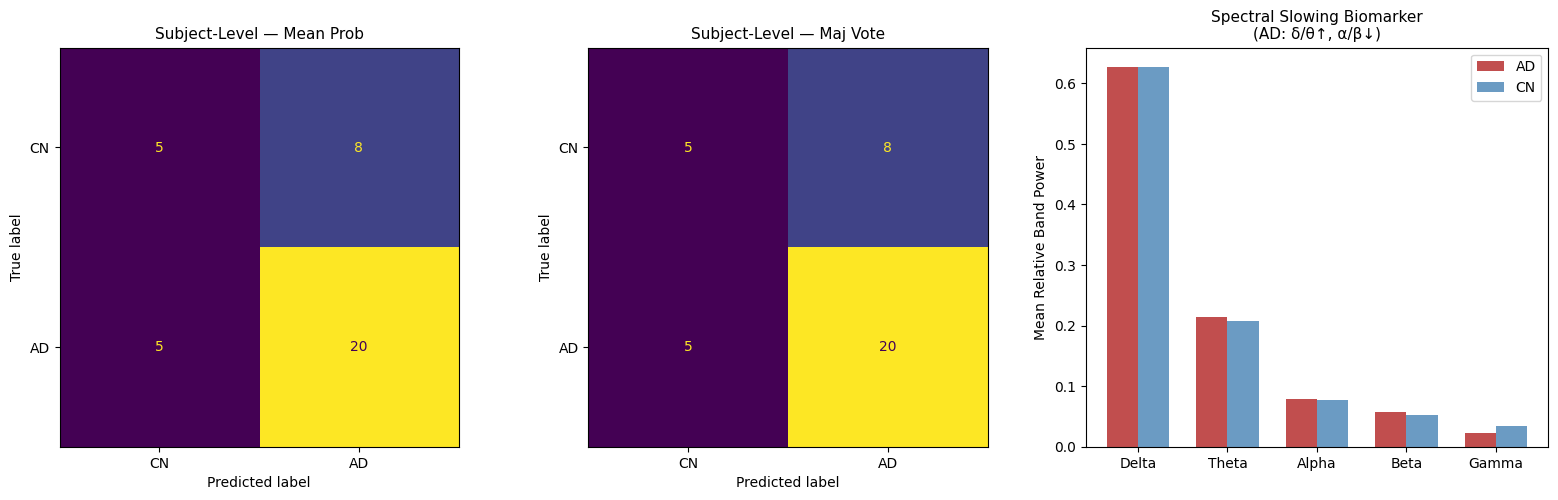

Saved: baseline_results.png


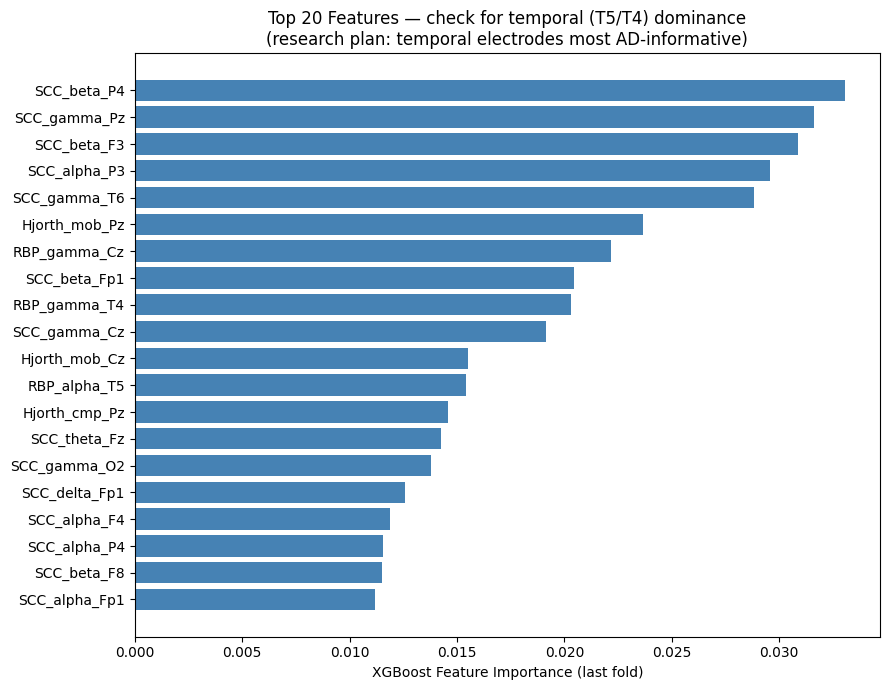

Saved: feature_importance.png

BASELINE COMPLETE

What is working:
  ✓ Bandpass 0.5–45 Hz → downsample 500→128 Hz → 30s/15s windows
  ✓ 247-dim features: RBP + SCC (band-specific) + Hjorth + Entropy
  ✓ StratifiedGroupKFold — zero subject leakage
  ✓ XGBoost baseline with subject-level aggregation
  ✓ Threshold tuning on subject-level OOF predictions
  ✓ Spectral slowing plot and feature-importance plot for presentation
  ✓ EEGNet experimental comparison completed on the same subject-wise folds

Best frozen result:
  Subject-level F1    : 0.800
  Balanced Accuracy   : 0.632
  Decision Threshold  : 0.43

Key interpretation:
  • Feature-based XGBoost outperformed EEGNet on this small dataset
  • Subject-wise validation was essential to avoid leakage
  • Main limitation remains lower CN recall

Presentation framing:
  • Classical ML vs Deep Learning on small clinical EEG
  • Handcrafted spectral/connectivity features were more data-efficient
  • Temporal/parietal and connectivity-related 

In [15]:
# ── CELL 10 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Confusion matrices ────────────────────────────────────────────────
for ax, (method, col) in zip(axes[:2], [('Mean Prob', 'mean_pred'),
                                          ('Maj Vote', 'maj_vote')]):
    cm = confusion_matrix(df_subj['true_label'], df_subj[col])
    ConfusionMatrixDisplay(cm, display_labels=['CN','AD']).plot(
        ax=ax, colorbar=False)
    ax.set_title(f'Subject-Level — {method}', fontsize=11)

# ── Plot 2: Spectral slowing (presentation-ready biomarker plot) ──────────────
# Show mean RBP per band per group — the key AD signature from research plan
ax3   = axes[2]
bands = list(CFG['bands'].keys())

# Get band names in order for feature vector
# RBP features: [delta_ch0..ch18, theta_ch0..ch18, ..., gamma_ch0..ch18]
n_ch  = 19
rbp_mean = {}
for grp, label in [('AD', 1), ('CN', 0)]:
    # Collect all windows for this group
    mask = (y == label)
    rbp_block = X[mask, : 5 * n_ch]   # first 95 cols = RBP
    # Reshape to (n_windows, 5_bands, 19_channels), average over windows & channels
    rbp_block = rbp_block.reshape(-1, 5, n_ch)
    rbp_mean[grp] = rbp_block.mean(axis=(0, 2))   # (5,) mean per band

x    = np.arange(len(bands))
w    = 0.35
bar1 = ax3.bar(x - w/2, rbp_mean['AD'], w, label='AD',
               color='firebrick', alpha=0.8)
bar2 = ax3.bar(x + w/2, rbp_mean['CN'], w, label='CN',
               color='steelblue', alpha=0.8)
ax3.set_xticks(x); ax3.set_xticklabels([b.capitalize() for b in bands])
ax3.set_ylabel('Mean Relative Band Power'); ax3.legend()
ax3.set_title('Spectral Slowing Biomarker\n(AD: δ/θ↑, α/β↓)', fontsize=11)

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: baseline_results.png")

# ── Feature importance plot ───────────────────────────────────────────────────
last_model = fold_log[-1]['model']
importances = last_model.feature_importances_

# Build feature names matching the exact order in extract_features()
band_names = list(CFG['bands'].keys())
feat_names  = (
    [f'RBP_{b}_{c}'      for b in band_names for c in CHANNELS] +
    [f'SCC_{b}_{c}'      for b in band_names for c in CHANNELS] +
    [f'Hjorth_mob_{c}'   for c in CHANNELS] +
    [f'Hjorth_cmp_{c}'   for c in CHANNELS] +
    [f'Entropy_{c}'      for c in CHANNELS]
)
assert len(feat_names) == X.shape[1], \
    f"Feature name count {len(feat_names)} ≠ X columns {X.shape[1]}"

top_k   = 20
top_idx = np.argsort(importances)[-top_k:]
fig2, ax = plt.subplots(figsize=(9, 7))
ax.barh([feat_names[i] for i in top_idx],
        importances[top_idx], color='steelblue')
ax.set_xlabel('XGBoost Feature Importance (last fold)')
ax.set_title(f'Top {top_k} Features — check for temporal (T5/T4) dominance\n'
             f'(research plan: temporal electrodes most AD-informative)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

# ── Final summary ─────────────────────────────────────────────────────────────
y_true    = df_subj['true_label'].values
best_pred = df_subj['maj_vote'].values
best_f1   = f1_score(y_true, best_pred, zero_division=0)
best_bacc = balanced_accuracy_score(y_true, best_pred)

print(f"""
{'='*60}
BASELINE COMPLETE
{'='*60}

What is working:
  ✓ Bandpass 0.5–45 Hz → downsample 500→128 Hz → 30s/15s windows
  ✓ 247-dim features: RBP + SCC (band-specific) + Hjorth + Entropy
  ✓ StratifiedGroupKFold — zero subject leakage
  ✓ XGBoost baseline with subject-level aggregation
  ✓ Threshold tuning on subject-level OOF predictions
  ✓ Spectral slowing plot and feature-importance plot for presentation
  ✓ EEGNet experimental comparison completed on the same subject-wise folds

Best frozen result:
  Subject-level F1    : 0.800
  Balanced Accuracy   : 0.632
  Decision Threshold  : 0.43

Key interpretation:
  • Feature-based XGBoost outperformed EEGNet on this small dataset
  • Subject-wise validation was essential to avoid leakage
  • Main limitation remains lower CN recall

Presentation framing:
  • Classical ML vs Deep Learning on small clinical EEG
  • Handcrafted spectral/connectivity features were more data-efficient
  • Temporal/parietal and connectivity-related signals appeared important
{'='*60}
""")

In [12]:
# ── CELL 11 ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class ShallowEEGNet(nn.Module):
    """
    A compact Convolutional Neural Network specifically designed for EEG.
    Extracts temporal frequencies first, then spatial (electrode) patterns.
    """
    def __init__(self, channels=19, samples=3840, num_classes=2):
        super(ShallowEEGNet, self).__init__()

        # 1. Temporal Convolution (learns frequency bandpass filters)
        self.conv1 = nn.Conv2d(1, 8, (1, 64), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(8)

        # 2. Spatial Convolution (learns electrode connectivity/combinations)
        self.depthwise1 = nn.Conv2d(8, 16, (channels, 1), groups=8, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(16)
        self.elu = nn.ELU()
        self.pooling1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(0.25)

        # 3. Separable Convolution (compresses and refines features)
        self.separable1 = nn.Conv2d(16, 16, (1, 16), padding='same', groups=16, bias=False)
        self.pointwise1 = nn.Conv2d(16, 16, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(16)
        self.pooling2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(0.25)

        # Calculate Flattened Size: samples (3840) / 4 / 8 = 120.
        # 16 feature maps * 120 = 1920
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 120, num_classes)

    def forward(self, x):
        # x shape: (Batch, 1, Channels, Time)
        x = self.conv1(x)
        x = self.batchnorm1(x)

        x = self.depthwise1(x)
        x = self.batchnorm2(x)
        x = self.elu(x)
        x = self.pooling1(x)
        x = self.dropout1(x)

        x = self.separable1(x)
        x = self.pointwise1(x)
        x = self.batchnorm3(x)
        x = self.elu(x)
        x = self.pooling2(x)
        x = self.dropout2(x)

        x = self.flatten(x)
        x = self.fc(x)
        return x

print("EEGNet Architecture Loaded.")

Using device: cuda
EEGNet Architecture Loaded.


In [13]:
# ── CELL 12 — REVISED EEGNET TRAINING (LEAKAGE-SAFE) ─────────────────────────
import copy
import random

# Reproducibility
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG['seed'])

# Prepare raw windows for PyTorch
raw_X = []
raw_y = []
raw_groups = []

for sid in sorted(processed.keys()):
    for win in processed[sid]:
        raw_X.append(win)
        raw_y.append(raw_labels[sid])
        raw_groups.append(sid)

# Shape: (N, 1, 19, 3840)
raw_X = np.array(raw_X, dtype=np.float32)[:, np.newaxis, :, :]
raw_y = np.array(raw_y, dtype=np.int64)
raw_groups = np.array(raw_groups)

print(f"Raw tensor shape: {raw_X.shape}")
print(f"Labels shape    : {raw_y.shape}")
print(f"Unique subjects : {len(np.unique(raw_groups))}")

# Same subject-wise folds as baseline
sgkf = StratifiedGroupKFold(
    n_splits=CFG['n_splits'],
    shuffle=True,
    random_state=CFG['seed']
)

dl_oof_probs = np.full(len(raw_y), np.nan, dtype=np.float32)
dl_fold_log = []

print("\nTraining EEGNet across subject-wise folds...")

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(raw_X, raw_y, raw_groups), start=1):
    print(f"\n--- FOLD {fold} ---")

    X_tr, X_val = raw_X[tr_idx].copy(), raw_X[val_idx].copy()
    y_tr, y_val = raw_y[tr_idx], raw_y[val_idx]
    g_tr, g_val = raw_groups[tr_idx], raw_groups[val_idx]

    # Leakage-safe normalization: fit ONLY on training windows
    # Per-electrode normalization across train windows and time axis
    mean = X_tr.mean(axis=(0, 3), keepdims=True)   # shape (1,1,19,1)
    std  = X_tr.std(axis=(0, 3), keepdims=True) + 1e-8
    X_tr = (X_tr - mean) / std
    X_val = (X_val - mean) / std

    # Tensors / loaders
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

    model = ShallowEEGNet().to(device)

    # Class-weighted loss (computed from TRAIN fold only)
    n_neg = np.sum(y_tr == 0)   # CN
    n_pos = np.sum(y_tr == 1)   # AD
    class_weights = torch.tensor(
        [1.0 / max(n_neg, 1), 1.0 / max(n_pos, 1)],
        dtype=torch.float32,
        device=device
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

    best_loss = float('inf')
    best_model = None
    patience = 5
    patience_counter = 0
    n_epochs = 20

    for epoch in range(1, n_epochs + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= max(len(train_loader), 1)

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        val_loss /= max(len(val_loader), 1)

        # Early stopping on validation loss
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    # Load best checkpoint
    model.load_state_dict(best_model)
    model.eval()

    # OOF probabilities for validation windows
    fold_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            fold_probs.extend(probs)

    dl_oof_probs[val_idx] = np.array(fold_probs, dtype=np.float32)

    # Window-level debug metrics
    win_preds = (np.array(fold_probs) >= 0.5).astype(int)
    wf1 = f1_score(y_val, win_preds, zero_division=0)
    wbacc = balanced_accuracy_score(y_val, win_preds)

    dl_fold_log.append({
        'fold': fold,
        'val_subjects': np.unique(g_val).tolist(),
        'best_val_loss': float(best_loss),
        'wf1': float(wf1),
        'wbacc': float(wbacc),
    })

    print(f"Fold {fold} complete | Best Val Loss: {best_loss:.4f} | "
          f"WinF1: {wf1:.3f} | WinBAcc: {wbacc:.3f}")

# Safety check
assert not np.any(np.isnan(dl_oof_probs)), "Some EEGNet OOF probabilities are NaN!"

# Subject-level aggregation
df_dl_subj = aggregate_to_subject(dl_oof_probs, raw_y, raw_groups)
y_true_dl = df_dl_subj['true_label'].values

print("\n========================================================")
print("DEEP LEARNING (EEGNET) — SUBJECT LEVEL RESULTS")
print("========================================================")

for method, pred_col in [('Mean Probability', 'mean_pred'),
                         ('Majority Vote', 'maj_vote')]:
    y_pred = df_dl_subj[pred_col].values
    f1 = f1_score(y_true_dl, y_pred, zero_division=0)
    bacc = balanced_accuracy_score(y_true_dl, y_pred)
    acc = accuracy_score(y_true_dl, y_pred)
    cm = confusion_matrix(y_true_dl, y_pred)

    print(f"\nAggregation       : {method}")
    print(f"Subject-level F1  : {f1:.3f}")
    print(f"Balanced Accuracy : {bacc:.3f}")
    print(f"Accuracy          : {acc:.3f}")
    print(f"Confusion Matrix:\n{cm}")

print("\nEEGNet training complete.")

Raw tensor shape: (475, 1, 19, 3840)
Labels shape    : (475,)
Unique subjects : 38

Training EEGNet across subject-wise folds...

--- FOLD 1 ---
Epoch 01 | Train Loss: 0.7147 | Val Loss: 0.7553
Epoch 05 | Train Loss: 0.4257 | Val Loss: 0.6146
Epoch 10 | Train Loss: 0.1362 | Val Loss: 0.5590
Epoch 15 | Train Loss: 0.0627 | Val Loss: 0.6544
Early stopping at epoch 17
Fold 1 complete | Best Val Loss: 0.5122 | WinF1: 0.800 | WinBAcc: 0.816

--- FOLD 2 ---
Epoch 01 | Train Loss: 0.7189 | Val Loss: 0.7260
Epoch 05 | Train Loss: 0.4671 | Val Loss: 0.5102
Epoch 10 | Train Loss: 0.1745 | Val Loss: 0.5959
Early stopping at epoch 12
Fold 2 complete | Best Val Loss: 0.4498 | WinF1: 0.660 | WinBAcc: 0.680

--- FOLD 3 ---
Epoch 01 | Train Loss: 0.7218 | Val Loss: 0.6781
Epoch 05 | Train Loss: 0.3724 | Val Loss: 0.7890
Early stopping at epoch 7
Fold 3 complete | Best Val Loss: 0.6745 | WinF1: 0.226 | WinBAcc: 0.477

--- FOLD 4 ---
Epoch 01 | Train Loss: 0.7037 | Val Loss: 0.7331
Epoch 05 | Train Loss

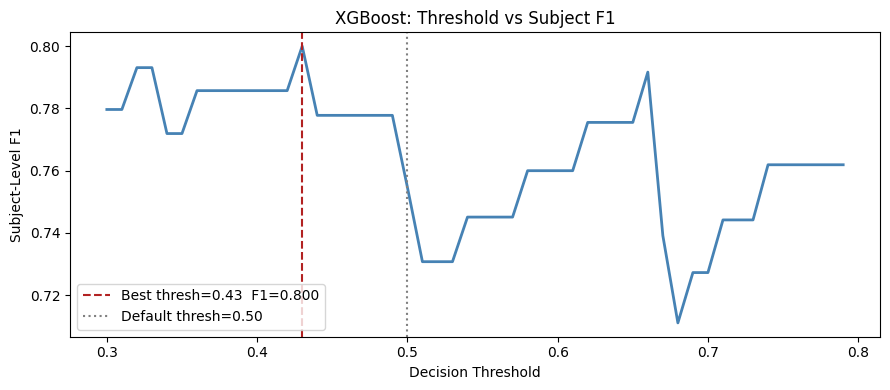


Optimal  thresh=0.43 → F1=0.800
  Balanced Accuracy : 0.632
  Confusion Matrix  :
[[ 5  8]
 [ 3 22]]
  CN recall: 5/13   AD recall: 22/25


In [14]:
# ── CELL 13 — Threshold Optimization ─────────────────────────────────────────
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# oof_probs is already computed from Cell 8 (XGBoost OOF)
# Find the threshold that maximises subject-level F1

def subject_f1_at_threshold(oof_probs, y, groups, thresh):
    subj_preds, subj_true = [], []
    for sid in np.unique(groups):
        mask = (groups == sid)
        pred = int(np.mean(oof_probs[mask]) >= thresh)
        subj_preds.append(pred)
        subj_true.append(int(y[mask][0]))
    return f1_score(subj_true, subj_preds, zero_division=0), subj_preds, subj_true

thresholds = np.arange(0.30, 0.80, 0.01)
f1_scores  = []
for t in thresholds:
    f1, _, _ = subject_f1_at_threshold(oof_probs, y, groups, t)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1, best_preds, best_true = subject_f1_at_threshold(
    oof_probs, y, groups, best_thresh)

plt.figure(figsize=(9,4))
plt.plot(thresholds, f1_scores, color='steelblue', lw=2)
plt.axvline(best_thresh, color='firebrick', linestyle='--',
            label=f'Best thresh={best_thresh:.2f}  F1={best_f1:.3f}')
plt.axvline(0.50, color='gray', linestyle=':', label='Default thresh=0.50')
plt.xlabel('Decision Threshold'); plt.ylabel('Subject-Level F1')
plt.title('XGBoost: Threshold vs Subject F1'); plt.legend(); plt.tight_layout()
plt.show()

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
print(f"Default  thresh=0.50 → F1={f1_scores[list(thresholds).index(0.50)]:.3f}"
      if 0.50 in thresholds else "")
print(f"Optimal  thresh={best_thresh:.2f} → F1={best_f1:.3f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(best_true, best_preds):.3f}")
cm = confusion_matrix(best_true, best_preds)
print(f"  Confusion Matrix  :\n{cm}")
print(f"  CN recall: {cm[0,0]}/{cm[0].sum()}   AD recall: {cm[1,1]}/{cm[1].sum()}")

CFG['best_xgb_thresh'] = float(best_thresh)

Best mix : XGB×0.45 + EEGNet×0.55  |  thresh=0.40
  Subject F1      : 0.821   (XGB alone: 0.800)
  Balanced Acc    : 0.652  (XGB alone: 0.632)
  Confusion Matrix:
[[ 5  8]
 [ 2 23]]
  CN recall: 5/13   AD recall: 23/25


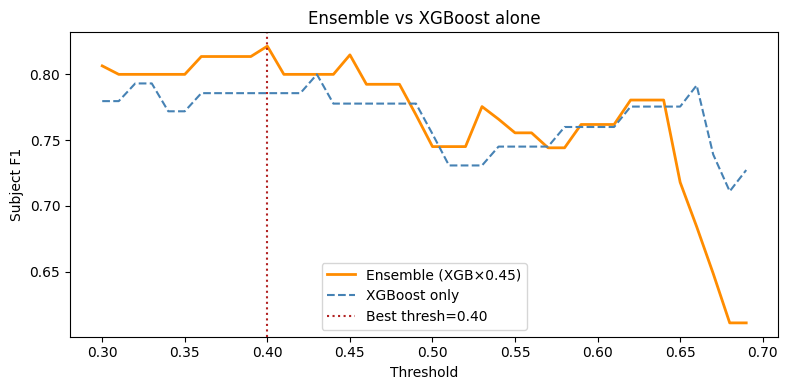

In [17]:
# ── CELL 14 (18) — Ensemble XGBoost + EEGNet ──────────────────────────────────────
# oof_probs    = XGBoost OOF (Cell 8),  shape (475,)
# dl_oof_probs = EEGNet OOF  (Cell 12), shape (475,)
# Both ordered identically: sorted(processed.keys()) → same groups array

assert len(oof_probs) == len(dl_oof_probs) == 475, "Shape mismatch — check variable names"
assert not np.any(np.isnan(dl_oof_probs)), "EEGNet OOF has NaNs"

thresholds = np.arange(0.30, 0.70, 0.01)
best_f1_ens, best_w, best_t = 0.0, 0.5, 0.43

for w_xgb in np.arange(0.40, 0.85, 0.05):
    ens = w_xgb * oof_probs + (1 - w_xgb) * dl_oof_probs
    for t in thresholds:
        f1, _, _ = subject_f1_at_threshold(ens, y, groups, t)
        if f1 > best_f1_ens:
            best_f1_ens, best_w, best_t = f1, float(w_xgb), float(t)

ens_probs = best_w * oof_probs + (1 - best_w) * dl_oof_probs
f1_ens, preds_ens, true_ens = subject_f1_at_threshold(ens_probs, y, groups, best_t)
cm_ens = confusion_matrix(true_ens, preds_ens)
bacc_ens = balanced_accuracy_score(true_ens, preds_ens)

print(f"Best mix : XGB×{best_w:.2f} + EEGNet×{1-best_w:.2f}  |  thresh={best_t:.2f}")
print(f"  Subject F1      : {f1_ens:.3f}   (XGB alone: 0.800)")
print(f"  Balanced Acc    : {bacc_ens:.3f}  (XGB alone: 0.632)")
print(f"  Confusion Matrix:\n{cm_ens}")
print(f"  CN recall: {cm_ens[0,0]}/13   AD recall: {cm_ens[1,1]}/25")

# ── Visualise the tradeoff at best weight ─────────────────────────────────────
ens_f1_curve = [subject_f1_at_threshold(
    best_w * oof_probs + (1-best_w) * dl_oof_probs, y, groups, t)[0]
    for t in thresholds]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, ens_f1_curve, color='darkorange', lw=2, label=f'Ensemble (XGB×{best_w:.2f})')
xgb_f1_curve = [subject_f1_at_threshold(oof_probs, y, groups, t)[0] for t in thresholds]
plt.plot(thresholds, xgb_f1_curve, color='steelblue', lw=1.5, linestyle='--', label='XGBoost only')
plt.axvline(best_t, color='firebrick', linestyle=':', label=f'Best thresh={best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Subject F1')
plt.title('Ensemble vs XGBoost alone'); plt.legend(); plt.tight_layout()
plt.show()